In [1]:
import numpy as np
import pandas as pd

import warnings
import math

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import cross_val_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import plot_utils

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [2]:
train_df = pd.read_csv("/kaggle/input/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/titanic/test.csv")

In [3]:
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


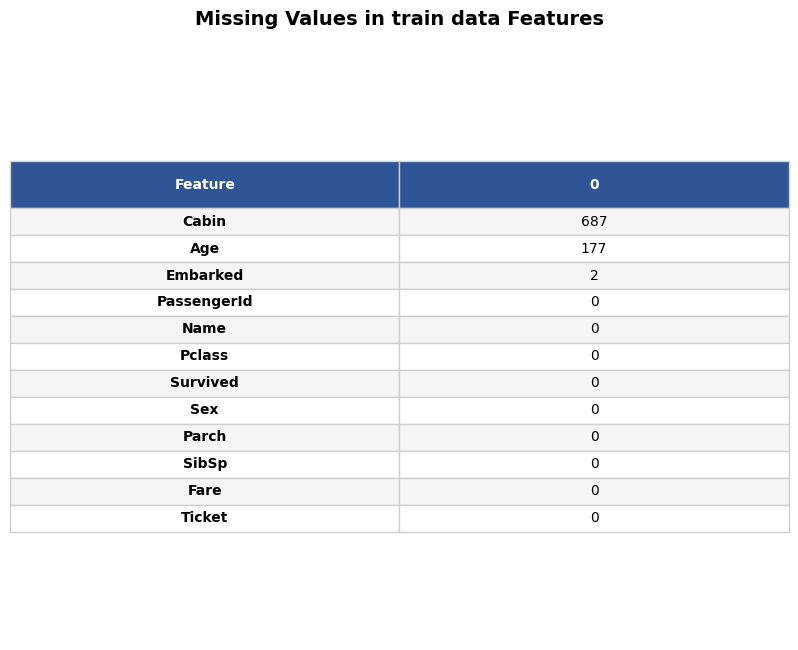

(<Figure size 800x660 with 1 Axes>,
 <Axes: title={'center': 'Missing Values in train data Features'}>)

In [5]:
plot_utils.plot_table(
    train_df.isnull().sum().sort_values(ascending = False).reset_index().rename(
        columns ={
            "index": "Feature",
            "target": "Missing Values"
        }
    ),
    title = "Missing Values in train data Features",
    precision = 3,
    row_colors=("#F5F5F5", "white")
)

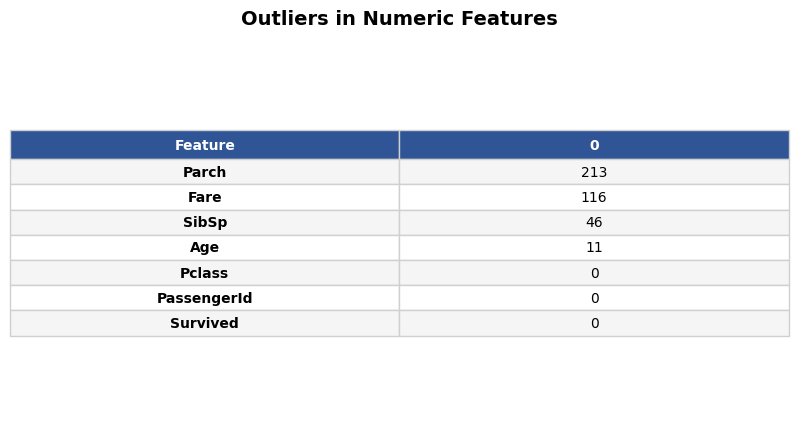

(<Figure size 800x435 with 1 Axes>,
 <Axes: title={'center': 'Outliers in Numeric Features'}>)

In [6]:
numeric_df = train_df.select_dtypes(include=["int64", "float64"])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))

plot_utils.plot_table(
    outliers.sum().sort_values(ascending = False).reset_index().rename(
        columns={
            "index": "Feature",
            "target": "Outliers"
        }
    ),
    title="Outliers in Numeric Features",
    precision=3
)

/kaggle/usr/lib/notebooks/alifazelniya/plot_utils/plot_utils.py:524: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


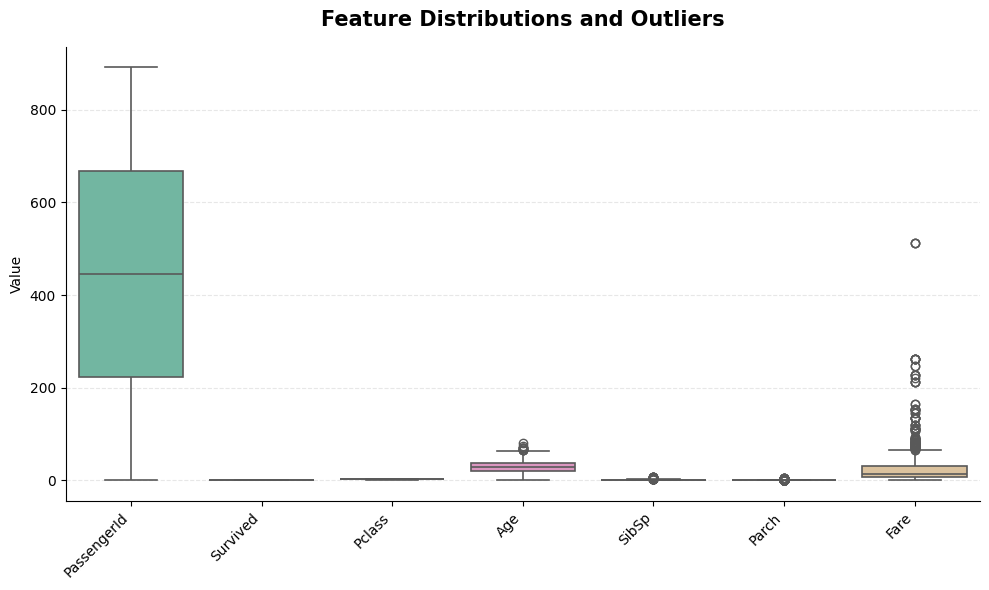

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Feature Distributions and Outliers'}, ylabel='Value'>)

In [7]:
plot_utils.plot_boxplots(numeric_df)

In [8]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


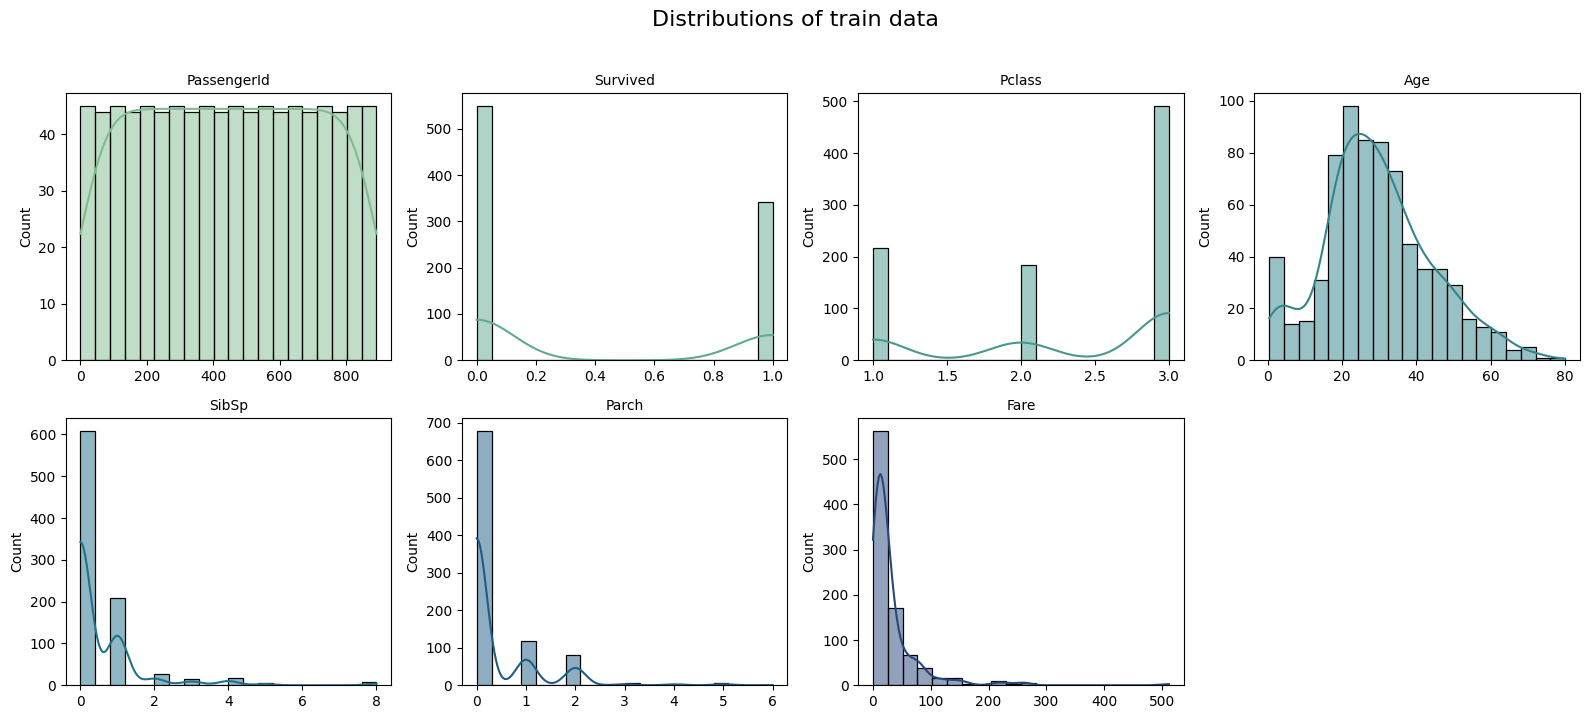

In [10]:
plot_utils.distribution_plot(numeric_df, 'train')

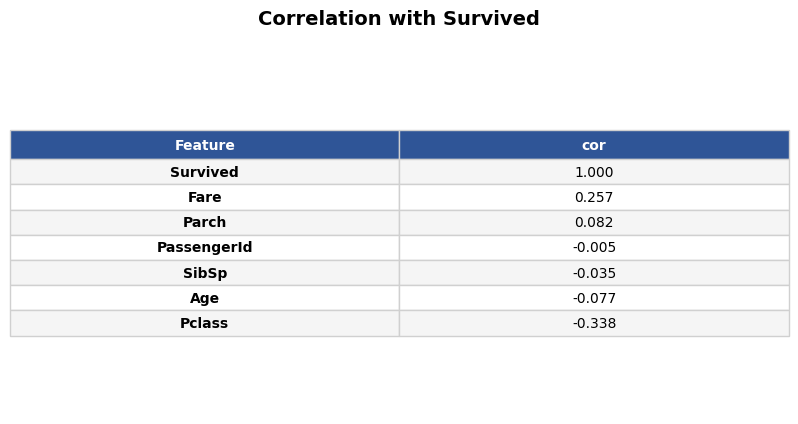

(<Figure size 800x435 with 1 Axes>,
 <Axes: title={'center': 'Correlation with Survived'}>)

In [11]:
corr_table = train_df[numeric_df.columns].corr()['Survived']

plot_utils.plot_table(
    corr_table.sort_values(ascending=False)
              .reset_index()
              .rename(columns={
                  'index': 'Feature',
                  'Survived': 'cor'
              }),
    title = "Correlation with Survived",
    precision=3
)

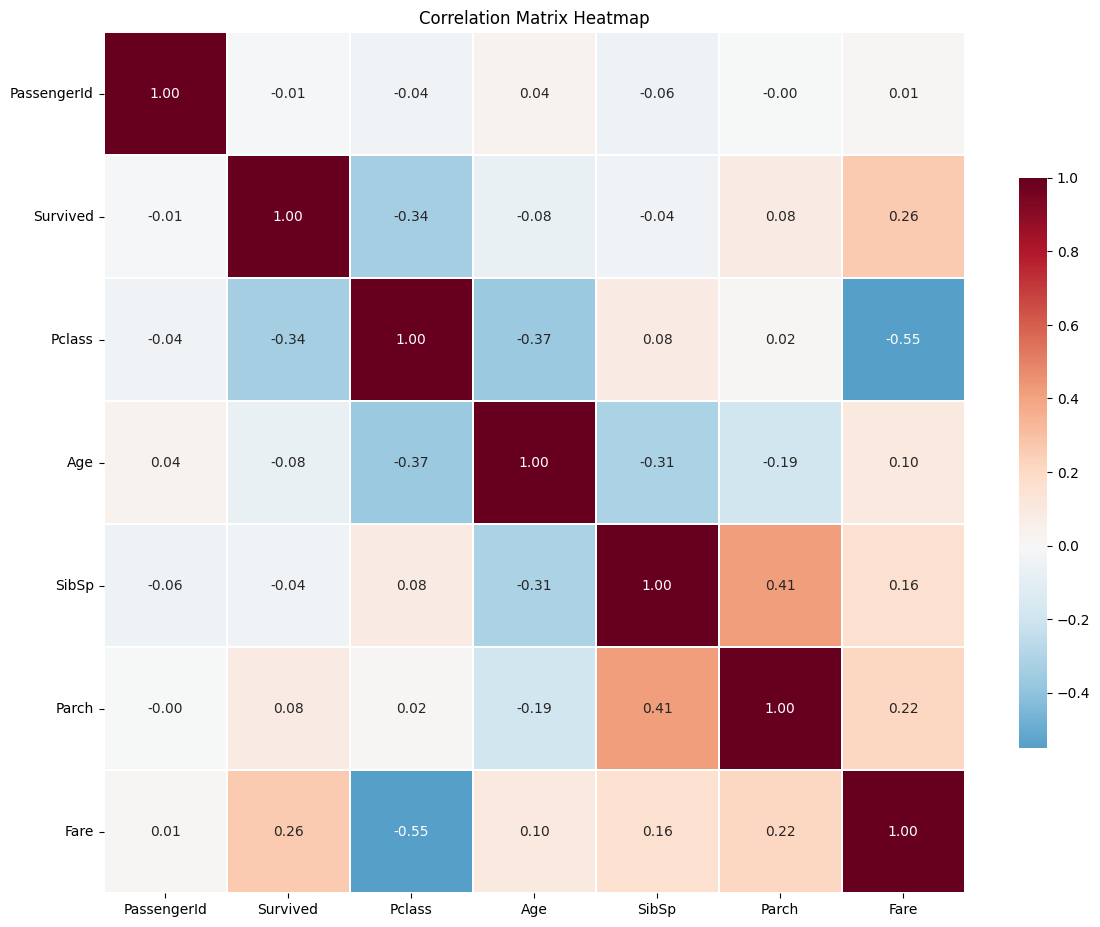

In [12]:
corr_matrix = train_df[numeric_df.columns].corr()

plot_utils.corr_plot(corr_matrix = corr_matrix)

In [13]:
train_df['is_train'] = 1 
test_df['is_train'] = 0 
full_df = pd.concat([train_df, test_df], ignore_index=True) 

In [14]:
full_df['Embarked'] = full_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [15]:
full_df['Fare'] = full_df['Fare'].fillna(full_df['Fare'].median())

In [16]:
full_df['Deck'] = full_df['Cabin'].str[0]
full_df['Deck'] = full_df['Deck'].fillna('Unknown')
full_df['HasCabin'] = full_df['Cabin'].notnull().astype(int)
full_df = full_df.drop(columns=['Cabin'])

In [17]:
full_df['Title'] = full_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'] 
full_df['Title'] = full_df['Title'].replace({ 'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs' }) 
full_df['Title'] = full_df['Title'].replace(rare_titles, 'Rare')

In [18]:
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1

In [19]:
categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck']
numeric_cols = ['Pclass', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'HasCabin']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

age_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

In [20]:
age_df = full_df.copy()

train_age = age_df[age_df['Age'].notnull()]
test_age  = age_df[age_df['Age'].isnull()]

age_features = [ 'Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'Deck', 'HasCabin' ]

age_model.fit(train_age[age_features], train_age['Age'])
predicted_ages = age_model.predict(test_age[age_features])
full_df.loc[full_df['Age'].isnull(), 'Age'] = predicted_ages 

In [21]:
full_df = full_df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [22]:
full_df = pd.get_dummies(full_df, columns=['Sex', 'Embarked', 'Title', 'Deck'], drop_first=True)

In [23]:
full_df['Fare'] = full_df['Fare'].map(lambda x: np.log(x + 1)) 

In [24]:
train_processed = full_df[full_df['is_train'] == 1].drop(columns=['is_train']) 
test_processed = full_df[full_df["is_train"] == 0].drop(columns=["is_train", "Survived"], errors="ignore")

In [25]:
train_processed.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,Sex_male,Embarked_Q,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0.0,3,22.0,1,0,2.110213,0,2,True,False,...,False,False,False,False,False,False,False,False,False,True
1,1.0,1,38.0,1,0,4.280593,1,2,False,False,...,True,False,False,True,False,False,False,False,False,False
2,1.0,3,26.0,0,0,2.188856,0,1,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1.0,1,35.0,1,0,3.990834,1,2,False,False,...,True,False,False,True,False,False,False,False,False,False
4,0.0,3,35.0,0,0,2.202765,0,1,True,False,...,False,False,False,False,False,False,False,False,False,True


In [26]:
test_processed.head()

,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,Sex_male,Embarked_Q,Embarked_S,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
891,3,34.5,0,0,2.178064,0,1,True,True,False,...,False,False,False,False,False,False,False,False,False,True
892,3,47.0,1,0,2.079442,0,2,False,False,True,...,True,False,False,False,False,False,False,False,False,True
893,2,62.0,0,0,2.369075,0,1,True,True,False,...,False,False,False,False,False,False,False,False,False,True
894,3,27.0,0,0,2.268252,0,1,True,False,True,...,False,False,False,False,False,False,False,False,False,True
895,3,22.0,1,1,2.586824,0,3,False,False,True,...,True,False,False,False,False,False,False,False,False,True


In [27]:
models_dict = {
    "Random Forest Classifier" : RandomForestClassifier(
                n_estimators = 600,
                max_depth = None,
                min_samples_split = 5,
                min_samples_leaf = 2,
                max_features = "sqrt",
                class_weight = "balanced_subsample",
                n_jobs = -1,
                random_state = 42
                ),
    
    "XGB Classifier" :   XGBClassifier(
                n_estimators = 1200,
                learning_rate = 0.03,
                max_depth = 5,
                subsample = 0.7,
                colsample_bytree = 0.7,
                min_child_weight = 3,
                gamma = 0.1,
                scale_pos_weight = 99,
                reg_alpha = 0.2,
                reg_lambda = 2,
                tree_method = "hist",
                eval_metric = "auc",
                random_state = 42
                ),

    "Logistic Regression" : LogisticRegression(
                max_iter = 3000,
                class_weight = "balanced",
                solver = "saga",
                C = 0.5,
                penalty = "l2"
                ),

    "LGBM Classifier" : LGBMClassifier(
                n_estimators = 1500,
                learning_rate = 0.03,
                num_leaves = 64,
                max_depth = -1,
                subsample = 0.7,
                colsample_bytree = 0.7,
                min_child_samples = 20,
                reg_alpha = 0.1,
                reg_lambda = 0.2,
                class_weight = "balanced",
                random_state = 42
                ),

    "CatBoostClassifier" : CatBoostClassifier(
                iterations = 1500,
                learning_rate = 0.03,
                depth = 8,
                l2_leaf_reg = 5,
                auto_class_weights = "Balanced",
                bagging_temperature = 0.5,
                random_seed = 42,
                verbose = 0
                )
    
}

In [28]:
def train_single_model(model_name, model, X_train, y_train, X_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    scores = cross_val_score(model, X_train, y_train, cv = 5, scoring="f1")

    result = {
        "Model": model_name,
        "y_pred": y_pred,
        "cv" : scores.mean()
    }

    return result

In [29]:
def run_models(X_train, y_train, X_test, models):

    all_y_pred = {}
    
    all_cv_scores = {}
    
    for model_name, model in models.items():
        print(f"\nTraining {model_name} ...")

        result = train_single_model(
            model_name,
            model,
            X_train,
            y_train,
            X_test
        )

        all_y_pred[model_name] = result["y_pred"]

        all_cv_scores[model_name] = result["cv"]
        
        print(f"{model_name} done.")

    return all_y_pred , all_cv_scores

In [30]:
Y_train_data = train_processed["Survived"]
X_train_data = train_processed.drop(columns = ["Survived"])

In [31]:
all_models_y_pred , all_models_cv_scores = run_models(X_train = X_train_data, y_train = Y_train_data, X_test = test_processed, models = models_dict)


Training Random Forest Classifier ...
Random Forest Classifier done.

Training XGB Classifier ...
XGB Classifier done.

Training Logistic Regression ...
Logistic Regression done.

Training LGBM Classifier ...
[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

In [32]:
y_pred = pd.DataFrame(all_models_y_pred)
y_pred.head()

,Random Forest Classifier,XGB Classifier,Logistic Regression,LGBM Classifier,CatBoostClassifier
0,0.0,0,0.0,0.0,0.0
1,0.0,0,1.0,0.0,0.0
2,0.0,1,0.0,0.0,0.0
3,0.0,1,0.0,1.0,1.0
4,1.0,1,1.0,1.0,1.0


In [33]:
df = pd.DataFrame.from_dict(all_models_cv_scores, orient = 'index', columns = ['cv_score'])
df.head()

,cv_score
Random Forest Classifier,0.765566
XGB Classifier,0.699765
Logistic Regression,0.756474
LGBM Classifier,0.751441
CatBoostClassifier,0.764517


In [34]:
best_model = df["cv_score"].idxmax()
best_model

'Random Forest Classifier'

In [35]:
best_preds = y_pred[best_model]

submission = pd.DataFrame({'PassengerId': test_df.PassengerId, 'Survived': best_preds})

submission.to_csv('/kaggle/working/submission.csv', index=False)

print("Your submission was successfully saved!")

Your submission was successfully saved!
